In [2]:
item_nm = '무'

import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost.callback import EarlyStopping

# 1. 데이터 불러오기
df = pd.read_csv('../data/무_월차낼게요.csv', encoding='cp949')
df = df.drop(columns=["등급코드"], errors="ignore")
df["week_start"] = pd.to_datetime(df["week_start"])
df = df.sort_values("week_start")

# 2. 주기 파생변수
df["week_sin"] = np.sin(2 * np.pi * df["week"] / 52)
df["week_cos"] = np.cos(2 * np.pi * df["week"] / 52)

# 3. 변화율 기반 파생변수
# 거래량 변화율
group_cols = ["직팜산지코드"]
df["총거래량_shifted"] = df.groupby(group_cols)["총거래량(kg)"].shift(1)
df["총거래량_변화율"] = np.where(
    df["총거래량_shifted"] == 0,
    0,
    (df["총거래량_shifted"] - df.groupby(group_cols)["총거래량(kg)"].shift(2)) / df.groupby(group_cols)["총거래량(kg)"].shift(2)
)

# 평균단가 전년비
df["평균단가_shifted"] = df.groupby(group_cols)["평균단가(원)"].shift(1)
df["평균단가_전년동주"] = df.groupby(group_cols)["평균단가_shifted"].shift(51)  # 총 52주 시프트
df["평균단가_전년비"] = (df["평균단가_shifted"] - df["평균단가_전년동주"]) / df["평균단가_전년동주"]




# 4. 변수 정의
target_col = "평균단가(원)"
lag_features = [col for col in df.columns if "_t-" in col]
derived_features = ["holiday_flag", "holiday_score", "grow_score"]
categorical_cols = ["품종코드"]
numeric_features = ["총거래량(kg)", "week_sin", "week_cos"]
change_features = ["총거래량_변화율", "평균단가_전년비"]

used_features = (
    numeric_features + lag_features + derived_features +
    categorical_cols + change_features + ["직팜산지코드", "year", "week", "week_start"]
)


In [3]:
# 5. 결측치 제거 + 2024년까지 학습데이터 선택
df_model = df.dropna(subset=[target_col] + used_features).copy()
df_model = df_model[df_model["year"] <= 2024].copy()

# 6. Label Encoding: 직팜산지코드
le = LabelEncoder()
df_model["직팜산지코드_le"] = le.fit_transform(df_model["직팜산지코드"])

# 7. 품종코드 원핫인코딩
df_model = pd.get_dummies(df_model, columns=["품종코드"])

# 8. 입력/출력 분리
y = df_model[target_col]
X = df_model.drop(columns=[target_col, "year", "week", "week_start", "직팜산지코드"], errors="ignore")
X = X.select_dtypes(include=[np.number]).astype(np.float32)

# 9. 스케일링 대상 변수
scale_cols = ["총거래량(kg)", "총거래량_변화율", "평균단가_전년비"]
scaler = ColumnTransformer(
    transformers=[
        ("scaler", RobustScaler(), scale_cols)
    ],
    remainder="passthrough",  # 나머지는 그대로 사용
    verbose_feature_names_out=False
)

# 10. 파이프라인 정의
pipe = Pipeline([
    ("transform", scaler)
])

# 11. Train/Validation 분할
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# 12. 스케일링 적용
X_train_scaled = pipe.fit_transform(X_train)
X_val_scaled = pipe.transform(X_val)

In [7]:
# 13. XGBoost 모델 정의
best_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=5,
    gamma=5,
    subsample=0.8,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1
)

# 14. 모델 학습 (조기 종료 포함)
best_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    callbacks=[EarlyStopping(rounds=30)],
    verbose=True
)

# 15. 검증 데이터 성능 평가
y_val_pred = best_model.predict(X_val_scaled)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae = mean_absolute_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)

print(f"✅ RMSE (val): {rmse:.2f}")
print(f"✅ MAE (val): {mae:.2f}")
print(f"✅ R² Score (val): {r2:.4f}")

[0]	validation_0-rmse:717.11703
[1]	validation_0-rmse:692.67387
[2]	validation_0-rmse:669.75710


c:\Users\Admin\anaconda3\envs\ten\lib\site-packages\xgboost\sklearn.py:835: UserWarning: `callbacks` in `fit` method is deprecated for better compatibility with scikit-learn, use `callbacks` in constructor or`set_params` instead.
  warnings.warn(


[3]	validation_0-rmse:648.07410
[4]	validation_0-rmse:627.38247
[5]	validation_0-rmse:608.56632
[6]	validation_0-rmse:590.66668
[7]	validation_0-rmse:574.01335
[8]	validation_0-rmse:560.25094
[9]	validation_0-rmse:545.38659
[10]	validation_0-rmse:531.45459
[11]	validation_0-rmse:518.33525
[12]	validation_0-rmse:505.94680
[13]	validation_0-rmse:494.58942
[14]	validation_0-rmse:483.97429
[15]	validation_0-rmse:475.06591
[16]	validation_0-rmse:467.03638
[17]	validation_0-rmse:458.32363
[18]	validation_0-rmse:451.17776
[19]	validation_0-rmse:443.07154
[20]	validation_0-rmse:436.78662
[21]	validation_0-rmse:429.87638
[22]	validation_0-rmse:423.69322
[23]	validation_0-rmse:417.84089
[24]	validation_0-rmse:412.42186
[25]	validation_0-rmse:407.36914
[26]	validation_0-rmse:402.75964
[27]	validation_0-rmse:398.50426
[28]	validation_0-rmse:394.32622
[29]	validation_0-rmse:390.55018
[30]	validation_0-rmse:386.99635
[31]	validation_0-rmse:383.70994
[32]	validation_0-rmse:380.77535
[33]	validation_0

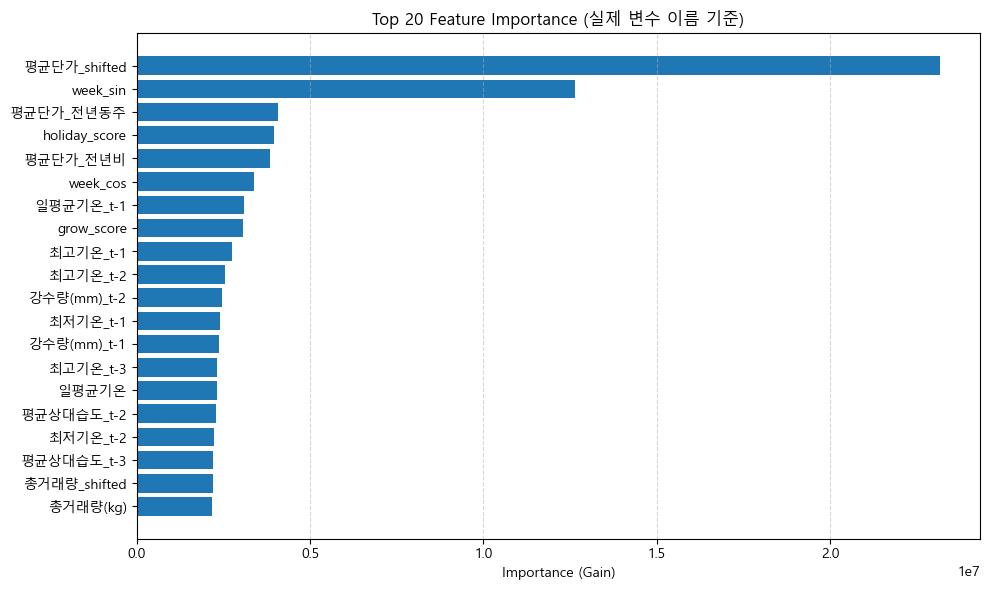

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 2. feature 이름 추출
feature_names = pipe.get_feature_names_out()

# 3. 중요도 추출 (f0, f1 등으로 반환됨)
importance = best_model.get_booster().get_score(importance_type="gain")

# 4. f0 → 실제 이름으로 매핑
mapped_importance = {
    feature_names[int(f[1:])]: score for f, score in importance.items()
}

# 5. DataFrame 변환 및 정렬
importance_df = pd.DataFrame({
    "feature": list(mapped_importance.keys()),
    "importance": list(mapped_importance.values())
}).sort_values("importance", ascending=False).reset_index(drop=True)

# 6. 시각화
top_n = 20
plt.figure(figsize=(10, 6))
plt.barh(
    importance_df["feature"][:top_n][::-1],
    importance_df["importance"][:top_n][::-1]
)
plt.xlabel("Importance (Gain)")
plt.title(f"Top {top_n} Feature Importance (실제 변수 이름 기준)")
plt.tight_layout()
plt.grid(True, axis="x", linestyle="--", alpha=0.5)
plt.show()

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 1. 2025년 테스트셋 준비
test_df = df[df["year"] == 2025].copy()
y_test = test_df["평균단가(원)"].copy()
test_df = test_df.drop(columns=["평균단가(원)"])

# 2. Label Encoding (직팜산지코드)
known_codes = set(le.classes_)
test_df = test_df[test_df["직팜산지코드"].isin(known_codes)].copy()
y_test = y_test.loc[test_df.index]
test_df["직팜산지코드_le"] = le.transform(test_df["직팜산지코드"])

# 3. 원핫인코딩 (품종코드)
test_df = pd.get_dummies(test_df, columns=["품종코드"])

# 4. 누락된 품종코드 컬럼 추가
missing_cols = set(df_model.columns) - set(test_df.columns)
missing_cols = [col for col in missing_cols if col.startswith("품종코드_")]
for col in missing_cols:
    test_df[col] = 0

# 5. 테스트셋 입력 데이터 구성
X_test = test_df.drop(columns=["year", "week", "week_start", "직팜산지코드"], errors="ignore")
X_test = X_test.select_dtypes(include=[np.number]).astype(np.float32)

# 6. 컬럼 순서 맞추기 + 스케일링 적용
X_test_scaled = pipe.transform(X_test)

# 7. 예측
y_pred = best_model.predict(X_test_scaled)

# 8. 성능 평가
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"✅ RMSE (test): {rmse:.2f}")
print(f"✅ MAE  (test): {mae:.2f}")
print(f"✅ R²   (test): {r2:.4f}")

✅ RMSE (test): 336.73
✅ MAE  (test): 403.00
✅ R²   (test): -0.6224


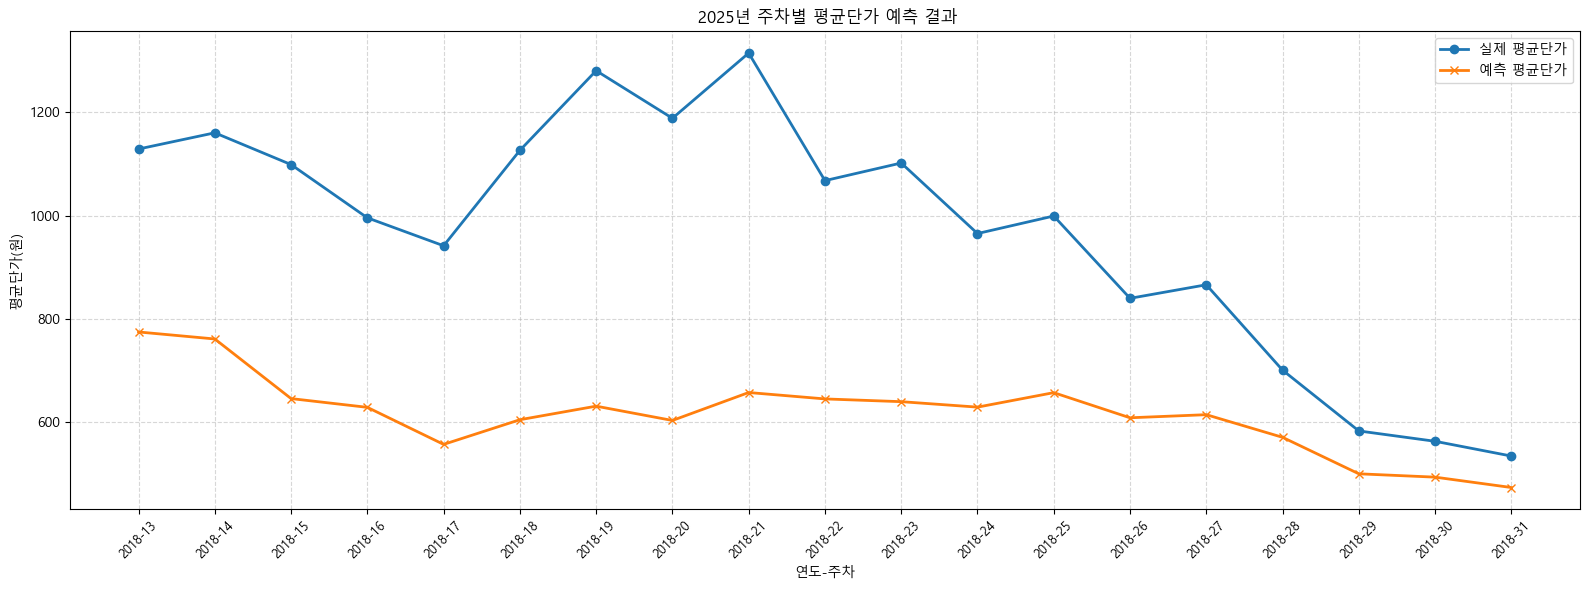

In [11]:
# 9. 시각화 준비
plot_df = test_df.reset_index(drop=True)
plot_df["실제값"] = y_test.reset_index(drop=True)
plot_df["예측값"] = y_pred
plot_df["year"] = df.loc[plot_df.index, "year"].values
plot_df["week"] = df.loc[plot_df.index, "week"].values

# 10. 주차별 평균 집계
weekly_avg = (
    plot_df.groupby(["year", "week"])[["실제값", "예측값"]]
    .mean()
    .reset_index()
)
weekly_avg["연도_주차"] = (
    weekly_avg["year"].astype(str) + "-" + weekly_avg["week"].astype(str).str.zfill(2)
)

# 11. 시각화
plt.figure(figsize=(16, 6))
plt.plot(weekly_avg["연도_주차"], weekly_avg["실제값"], label="실제 평균단가", marker="o", linewidth=2)
plt.plot(weekly_avg["연도_주차"], weekly_avg["예측값"], label="예측 평균단가", marker="x", linewidth=2)
plt.title(" 2025년 주차별 평균단가 예측 결과")
plt.xlabel("연도-주차")
plt.ylabel("평균단가(원)")
plt.xticks(rotation=45, fontsize=9)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

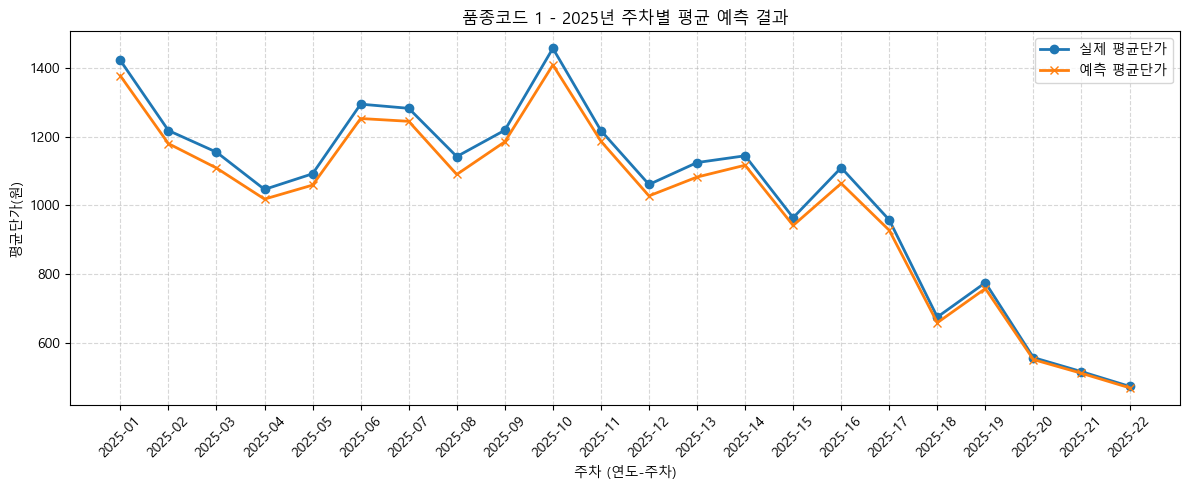

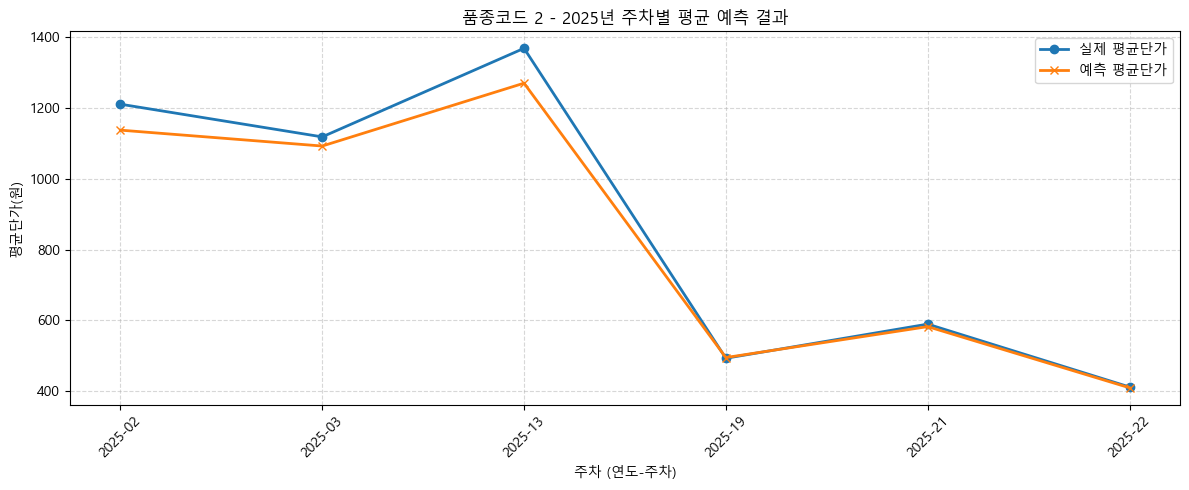

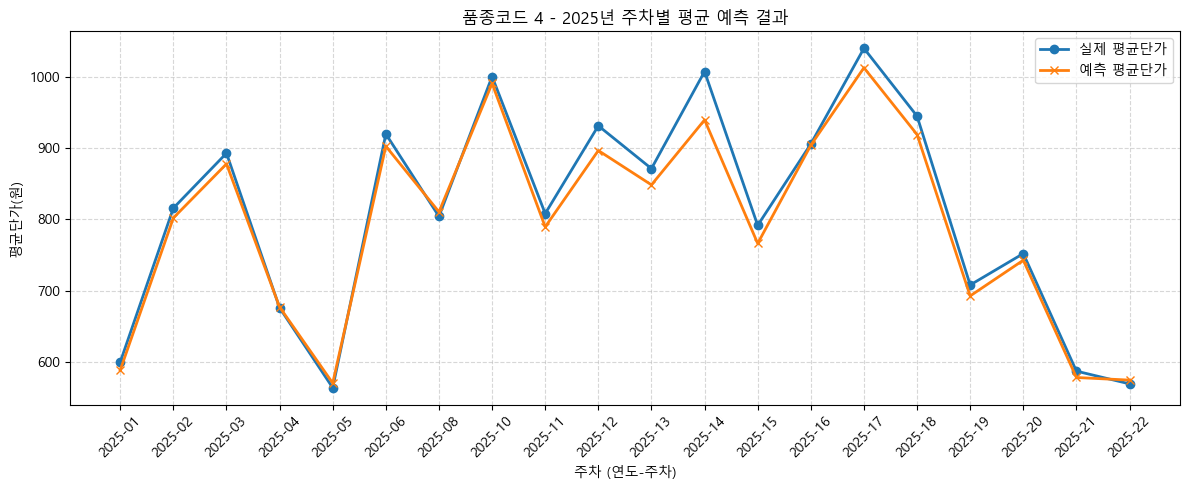

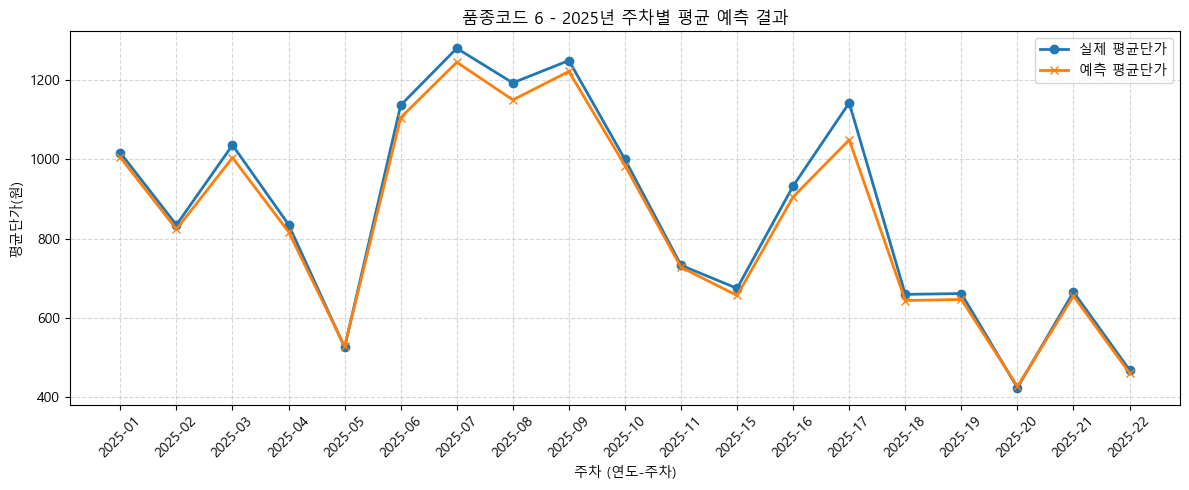

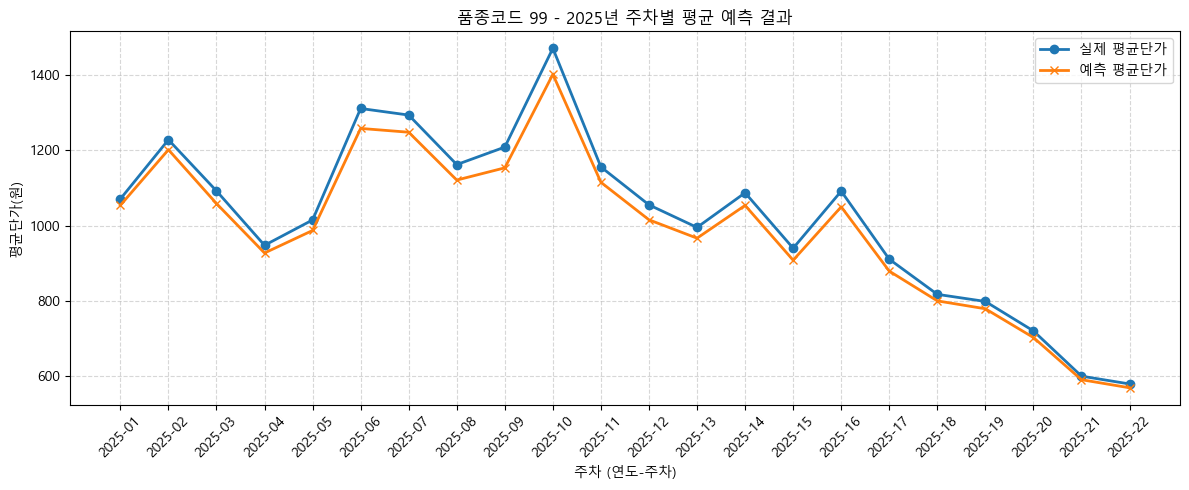

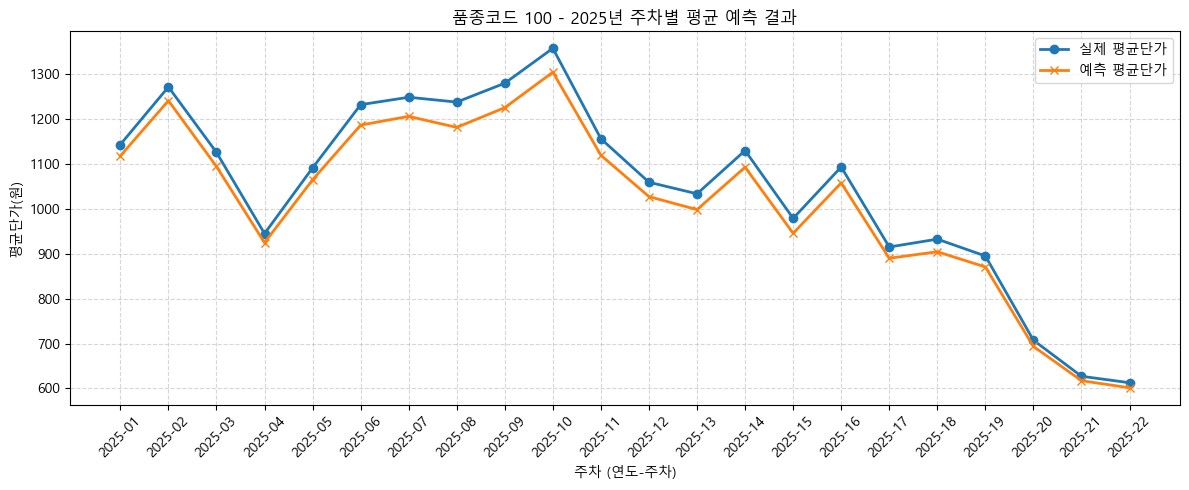

In [34]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 1. 2025년 테스트셋 준비
test_df = df[df["year"] == 2025].copy()
y_test = test_df["평균단가(원)"].copy()
test_df = test_df.drop(columns=["평균단가(원)"])

# 2. Label Encoding: 직팜산지코드
known_codes = set(le.classes_)
test_df = test_df[test_df["직팜산지코드"].isin(known_codes)].copy()
y_test = y_test.loc[test_df.index].reset_index(drop=True)
test_df["직팜산지코드_le"] = le.transform(test_df["직팜산지코드"])

# 3. 품종코드 보존
test_df["품종코드_raw"] = test_df["품종코드"]

# 4. 원핫인코딩 및 누락된 컬럼 채우기
test_df = pd.get_dummies(test_df, columns=["품종코드"])
model_cols = [col for col in df_model.columns if col.startswith("품종코드_")]
for col in model_cols:
    if col not in test_df.columns:
        test_df[col] = 0

# 5. 예측용 입력 데이터 구성
X_test = test_df.drop(columns=["year", "week", "week_start", "직팜산지코드"], errors="ignore")
X_test = X_test.select_dtypes(include=[np.number]).astype(np.float32)

# 6. 컬럼 순서 맞추기 + 스케일링 적용
X_test = X_test[pipe.get_feature_names_out()]  # pipe 기준으로 정렬
X_test_scaled = pipe.transform(X_test)

# 7. 예측 수행
y_pred = best_model.predict(X_test_scaled)

# 8. 결과 결합
result_df = test_df.reset_index(drop=True).copy()
result_df["실제값"] = y_test
result_df["예측값"] = y_pred
result_df["year"] = test_df["year"].values
result_df["week"] = test_df["week"].values
result_df["주차"] = result_df["year"].astype(str) + "-" + result_df["week"].astype(str).str.zfill(2)

# 9. 주차별 평균 계산
avg_weekly = (
    result_df.groupby(["품종코드_raw", "주차"], as_index=False)[["실제값", "예측값"]]
    .mean()
)

# 10. 품종별 시각화
for v in sorted(avg_weekly["품종코드_raw"].unique()):
    v_df = avg_weekly[avg_weekly["품종코드_raw"] == v].copy()

    plt.figure(figsize=(12, 5))
    plt.plot(v_df["주차"], v_df["실제값"], label="실제 평균단가", marker="o", linewidth=2)
    plt.plot(v_df["주차"], v_df["예측값"], label="예측 평균단가", marker="x", linewidth=2)
    plt.title(f"품종코드 {v} - 2025년 주차별 평균 예측 결과")
    plt.xlabel("주차 (연도-주차)")
    plt.ylabel("평균단가(원)")
    plt.xticks(rotation=45)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()